# Config

In [2]:
import pandas as pd
import openpyxl
import re
import ftfy
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
from plotnine import *
from config import RAW_DATA_DIR, PROCESSED_DATA_DIR, FIGURES_DIR, REPORTS_DIR
from plots import plot_satisfaction_bar, plot_target_correlations, analyze_ppe_usage, usage_summary
pd.set_option('future.no_silent_downcasting', True)

# Read data

In [3]:
file_path = PROCESSED_DATA_DIR / "survey_processed_data.xlsx"

datos_df = pd.read_excel(file_path, sheet_name="Datos")
print("Datos",datos_df.shape)

labels_df = pd.read_excel(file_path, sheet_name="Labels")
print("Labels",labels_df.shape)

variables_df = pd.read_excel(file_path, sheet_name="Variables")
print("Variables",variables_df.shape)

# codes_df = pd.read_excel(file_path, sheet_name="Codes")
# print("Codes",codes_df.shape)

Datos (1813, 540)
Labels (1813, 514)
Variables (514, 5)


# Plots

### Agreement with PPE statements

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 16 x 22 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\all_attitudes_comparison.png


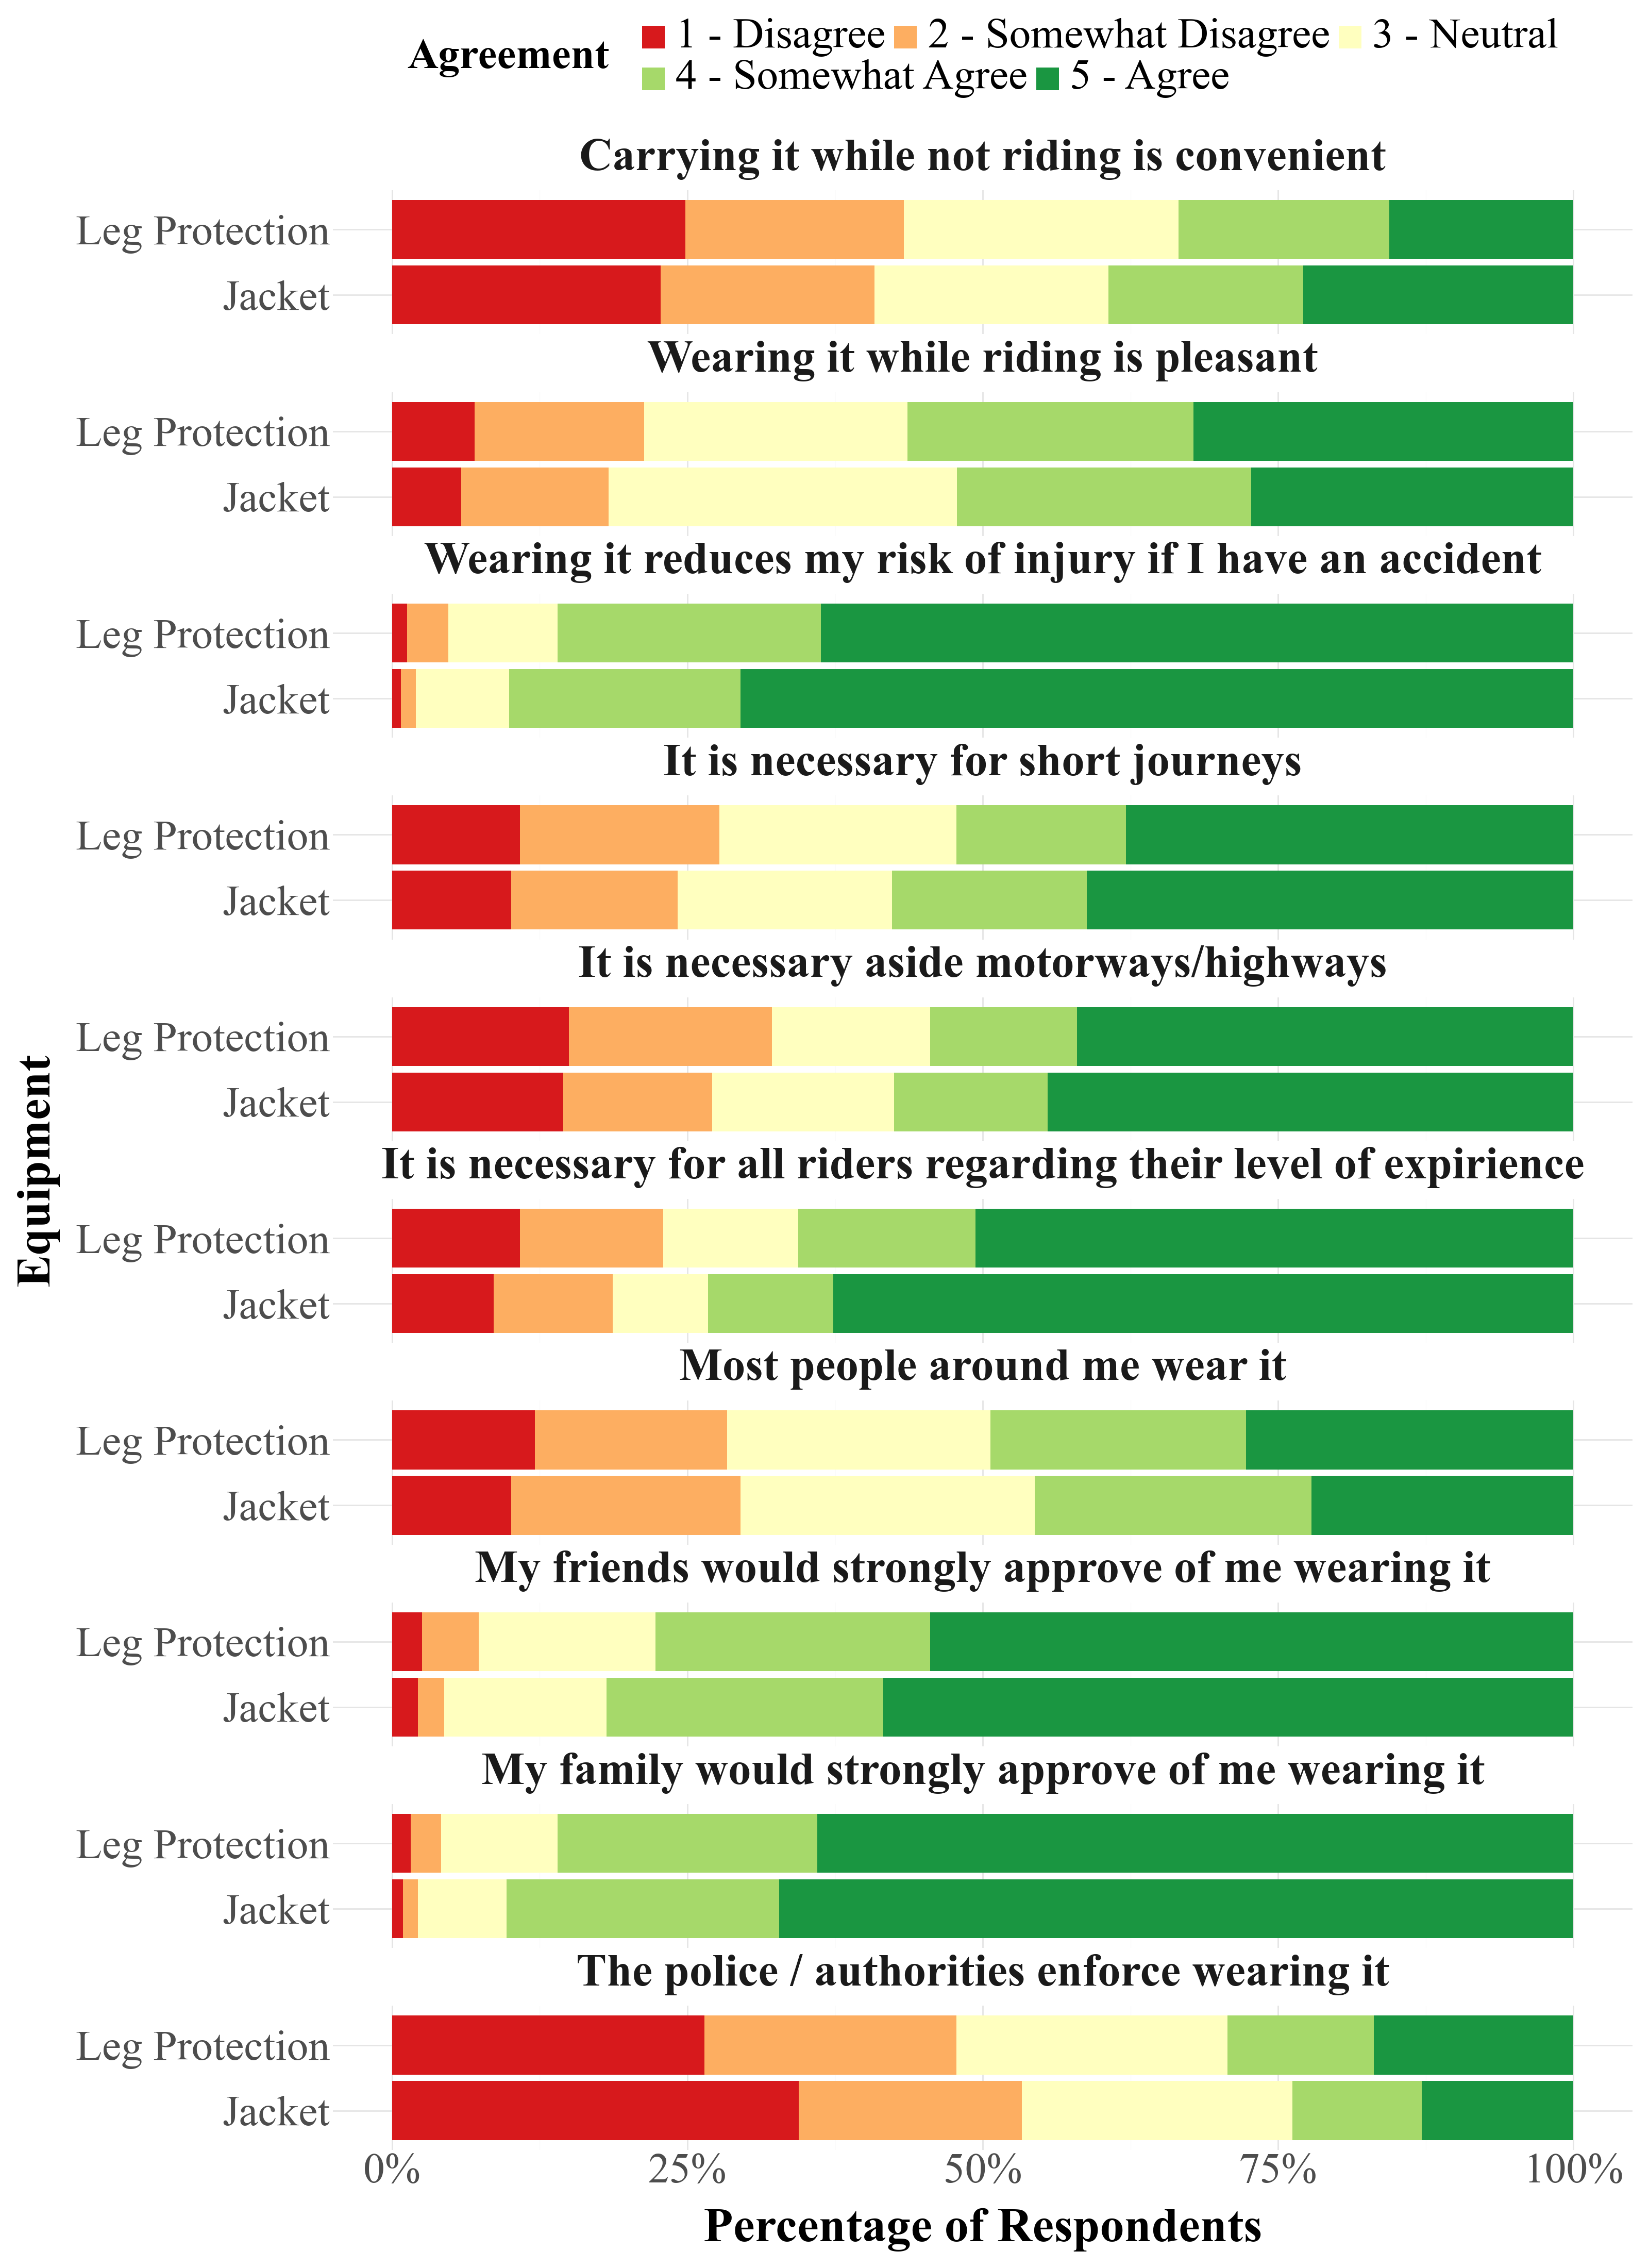

In [10]:
# 1. Define the exact labels you provided
statement_labels = {
    1: 'Carrying it while not riding is convenient',
    2: 'Wearing it while riding is pleasant',
    3: 'Wearing it reduces my risk of injury if I have an accident',
    4: 'It is necessary for short journeys',
    5: 'It is necessary aside motorways/highways',
    6: 'It is necessary for all riders regarding their level of expirience',
    7: 'Most people around me wear it',
    8: 'My friends would strongly approve of me wearing it',
    9: 'My family would strongly approve of me wearing it',
    10: 'The police / authorities enforce wearing it'
}

# 2. Build the column mapping dictionary dynamically
att_cols = {}
for i, label in statement_labels.items():
    att_cols[f'P15_{i}_recoded'] = ('Jacket', label)
    att_cols[f'P19_{i}_recoded'] = ('Leg Protection', label)

# 3. Melt the clean dataframe (datos_df) into a long format
att_long = (
    datos_df.melt(value_vars=list(att_cols.keys()), var_name='col', value_name='Score')
    .dropna(subset=['Score'])
)

# 4. Map the columns to Equipment and Statement
att_long['Equipment'] = att_long['col'].map(lambda x: att_cols[x][0])
att_long['Statement'] = att_long['col'].map(lambda x: att_cols[x][1])

# 5. Apply Likert mapping and categorical ordering
likert_map = {
    1.0: '1 - Disagree', 
    2.0: '2 - Somewhat Disagree', 
    3.0: '3 - Neutral', 
    4.0: '4 - Somewhat Agree', 
    5.0: '5 - Agree'
}

att_long['Response'] = pd.Categorical(
    att_long['Score'].map(likert_map), 
    categories=list(likert_map.values()), 
    ordered=True
)

att_long['Equipment'] = pd.Categorical(
    att_long['Equipment'], 
    categories=['Jacket', 'Leg Protection'], 
    ordered=True
)

# --- NEW FIX: Force the Statement order ---
# Extract the list of statements in their original 1-10 order
ordered_statements = list(statement_labels.values())

# Make the Statement column a categorical type with that specific order
att_long['Statement'] = pd.Categorical(
    att_long['Statement'], 
    categories=ordered_statements, 
    ordered=True
)

# 6. Generate the Plot 
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    
    # --- FIX IS HERE: Reverse the drawing order of the stacked bars ---
    + geom_bar(position=position_fill(reverse=True)) 
    
    + facet_wrap('~Statement', ncol=1) 
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn")
    + guides(fill=guide_legend(nrow=2, byrow=True))
    # (Note: The guides() line from the previous version is removed!)
    + labs(
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
            # Changed text from 18 to 22
            text=element_text(family='Times New Roman', size=35), 
            
            # Facet headers (e.g. "Jacket", "Leg Protection") changed from 18 to 22
            strip_text=element_text(size=32, fontweight='bold', margin={'b': 12}), 

            # Changed axis values (e.g., percentages) from 16 to 18
            axis_text=element_text(size=30), 
            
            # Changed axis labels (e.g. "Percentage of Respondents") from 18 to 22
            axis_title=element_text(size=34, fontweight='bold'), 
            
            # Increased legend sizes
            legend_text=element_text(size=30), 
            legend_title=element_text(size=30, fontweight='bold'), 
            
            # We might need to make the figure size slightly taller to accommodate the text. 
            # Bumped height from 20 to 22
            figure_size=(16, 22), 
            legend_position="top",
        )
)

plot_attitudes.save(FIGURES_DIR/"all_attitudes_comparison.png", dpi=300)
plot_attitudes


C:\Users\LucaLiebscht\AppData\Local\Temp\ipykernel_17224\285723317.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 16 x 22 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\all_attitudes_comparison_sorted.png


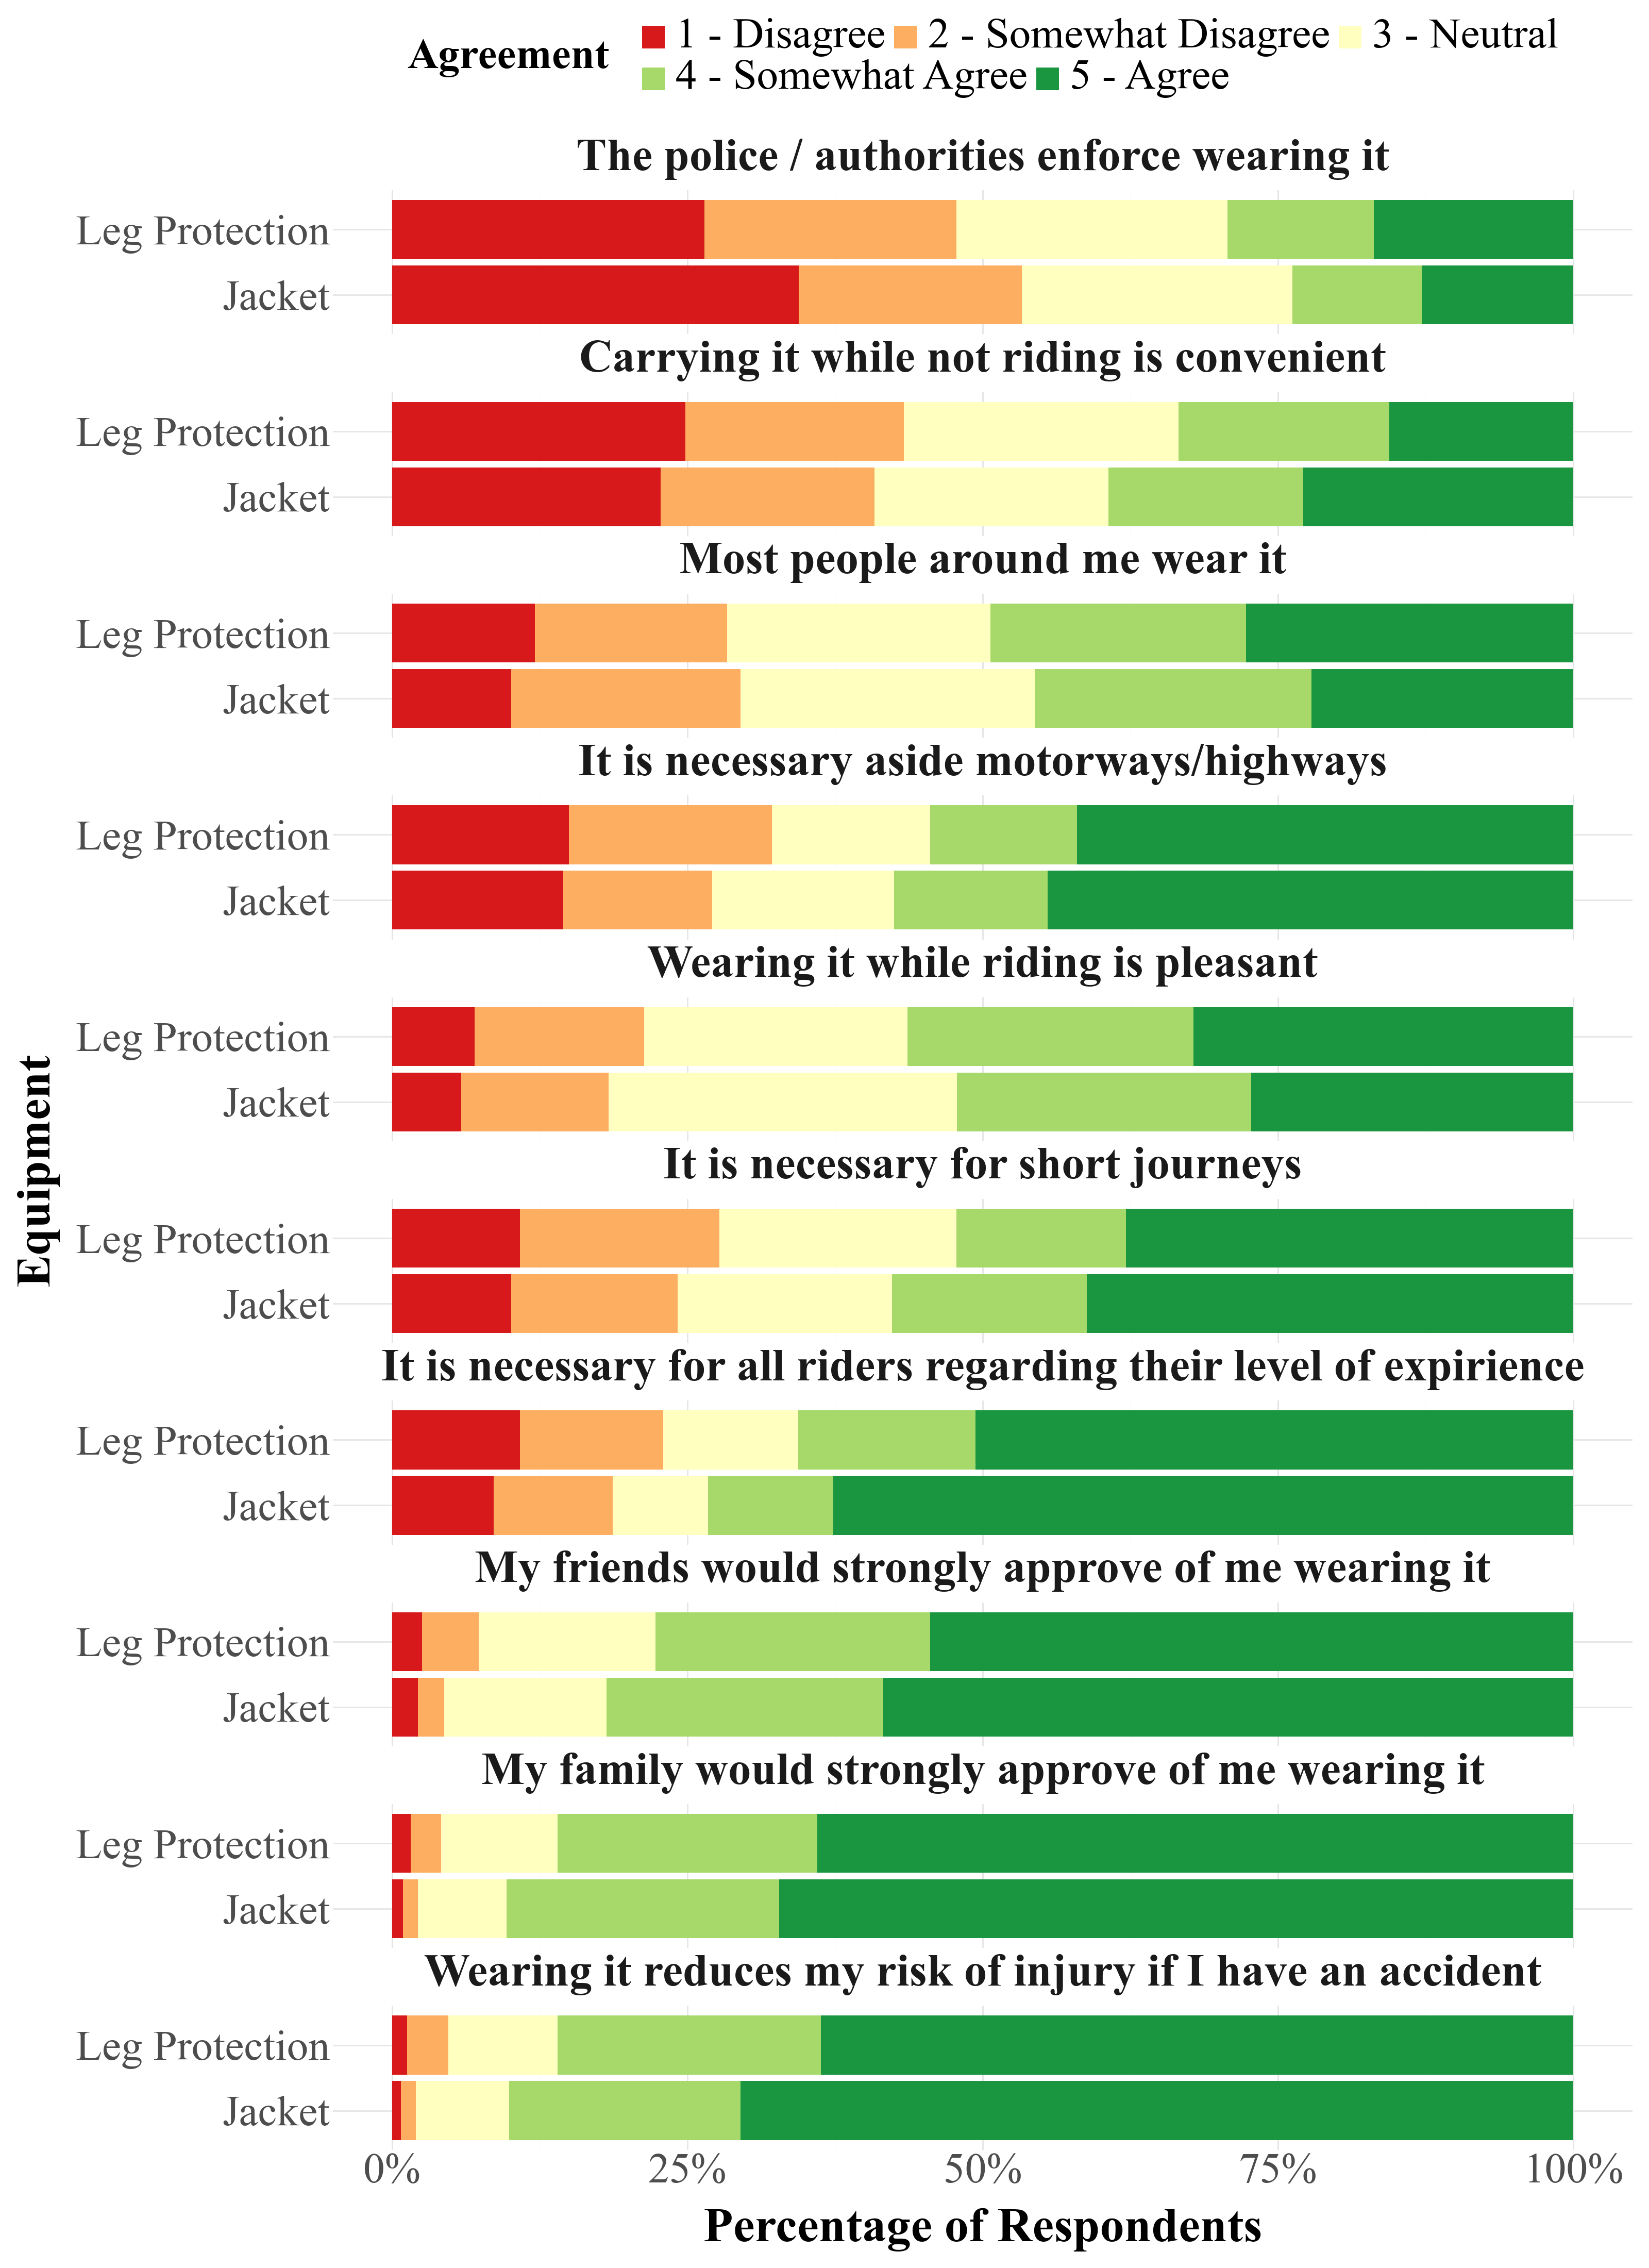

In [9]:
# ... (Steps 1 through 4 remain exactly the same) ...

# 5. Apply Likert mapping and categorical ordering
likert_map = {
    1.0: '1 - Disagree', 
    2.0: '2 - Somewhat Disagree', 
    3.0: '3 - Neutral', 
    4.0: '4 - Somewhat Agree', 
    5.0: '5 - Agree'
}

att_long['Response'] = pd.Categorical(
    att_long['Score'].map(likert_map), 
    categories=list(likert_map.values()), 
    ordered=True
)

att_long['Equipment'] = pd.Categorical(
    att_long['Equipment'], 
    categories=['Jacket', 'Leg Protection'], 
    ordered=True
)

# --- NEW FIX: Sort Statements by Average Score ---
# 1. Calculate the mean score for each statement (ignoring NaNs)
statement_means = att_long.groupby('Statement')['Score'].mean()

# 2. Sort the means in ascending order 
# (Lowest score = highest disagreement -> appears first at the top)
sorted_statements = statement_means.sort_values(ascending=True).index.tolist()

# 3. Apply this calculated order to the categorical variable
att_long['Statement'] = pd.Categorical(
    att_long['Statement'], 
    categories=sorted_statements, 
    ordered=True
)
# -------------------------------------------------

# 6. Generate the Plot 
plot_attitudes = (
    ggplot(att_long, aes(x='Equipment', fill='Response'))
    + geom_bar(position=position_fill(reverse=True)) 
    + facet_wrap('~Statement', ncol=1) 
    + coord_flip()
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn")

    + guides(fill=guide_legend(nrow=2, byrow=True))
    # (Note: The guides() line from the previous version is removed!)
    + labs(
        x=None,
        y="Percentage of Respondents",
        fill="Agreement"
    )
    + theme_minimal()
    + theme(
            # Changed text from 18 to 22
            text=element_text(family='Times New Roman', size=35), 
            
            # Facet headers (e.g. "Jacket", "Leg Protection") changed from 18 to 22
            strip_text=element_text(size=32, fontweight='bold', margin={'b': 12}), 

            # Changed axis values (e.g., percentages) from 16 to 18
            axis_text=element_text(size=30), 
            
            # Changed axis labels (e.g. "Percentage of Respondents") from 18 to 22
            axis_title=element_text(size=34, fontweight='bold'), 
            
            # Increased legend sizes
            legend_text=element_text(size=30), 
            legend_title=element_text(size=30, fontweight='bold'), 
            
            # We might need to make the figure size slightly taller to accommodate the text. 
            # Bumped height from 20 to 22
            figure_size=(16, 22), 
            legend_position="top",
        )
)




plot_attitudes.save(FIGURES_DIR/"all_attitudes_comparison_sorted.png", dpi=300)
plot_attitudes

### PPE usage

In [13]:


# 1. Define Standard Mappings
safety_map = {4.0: 'Always', 3.0: 'Most times', 2.0: 'Sometimes', 1.0: 'Never'}
safety_order = ["Always", "Most times", "Sometimes", "Never"]
ppe_rename = {'use_jacket': 'Jacket', 'use_leg': 'Leg Protection', 'use_helmet': 'Helmet'}

# 2. Create Categorical Columns
datos_df['use_jacket'] = datos_df['P13_recoded'].map(safety_map)
datos_df['use_leg'] = datos_df['P17_recoded'].map(safety_map)
datos_df['use_helmet'] = datos_df['P7_3_recoded'].map(safety_map)

# 3. Filter Ownership (P8#1 for Helmet)
datos_df.loc[datos_df['P8#1'] == 0, 'use_helmet'] = pd.NA

# 4. Melt and Clean for Plotting
ppe_df = (
    datos_df.melt(id_vars=['City'], value_vars=list(ppe_rename.keys()), 
                  var_name='PPE_Type', value_name='Usage')
    .dropna(subset=['Usage'])
)
ppe_df['PPE_Type'] = pd.Categorical(ppe_df['PPE_Type'].map(ppe_rename), 
                                   categories=['Helmet', 'Jacket', 'Leg Protection'], ordered=True)
ppe_df['Usage'] = pd.Categorical(ppe_df['Usage'], categories=safety_order, ordered=True)

# Define a Shared Theme to reduce repetitive code
shared_theme = theme_minimal() + theme(
    text=element_text(family='Times New Roman', size=18),
    plot_title=element_text(hjust=0.5, size=24, fontweight='bold'),
    strip_text=element_text(size=20, fontweight='bold'),
    axis_text=element_text(size=16),
    axis_title=element_text(size=18, fontweight='bold'),
    legend_text=element_text(size=16),
    legend_title=element_text(size=18, fontweight='bold'),
    legend_position="top",
    figure_size=(8, 12)
)

c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage.png


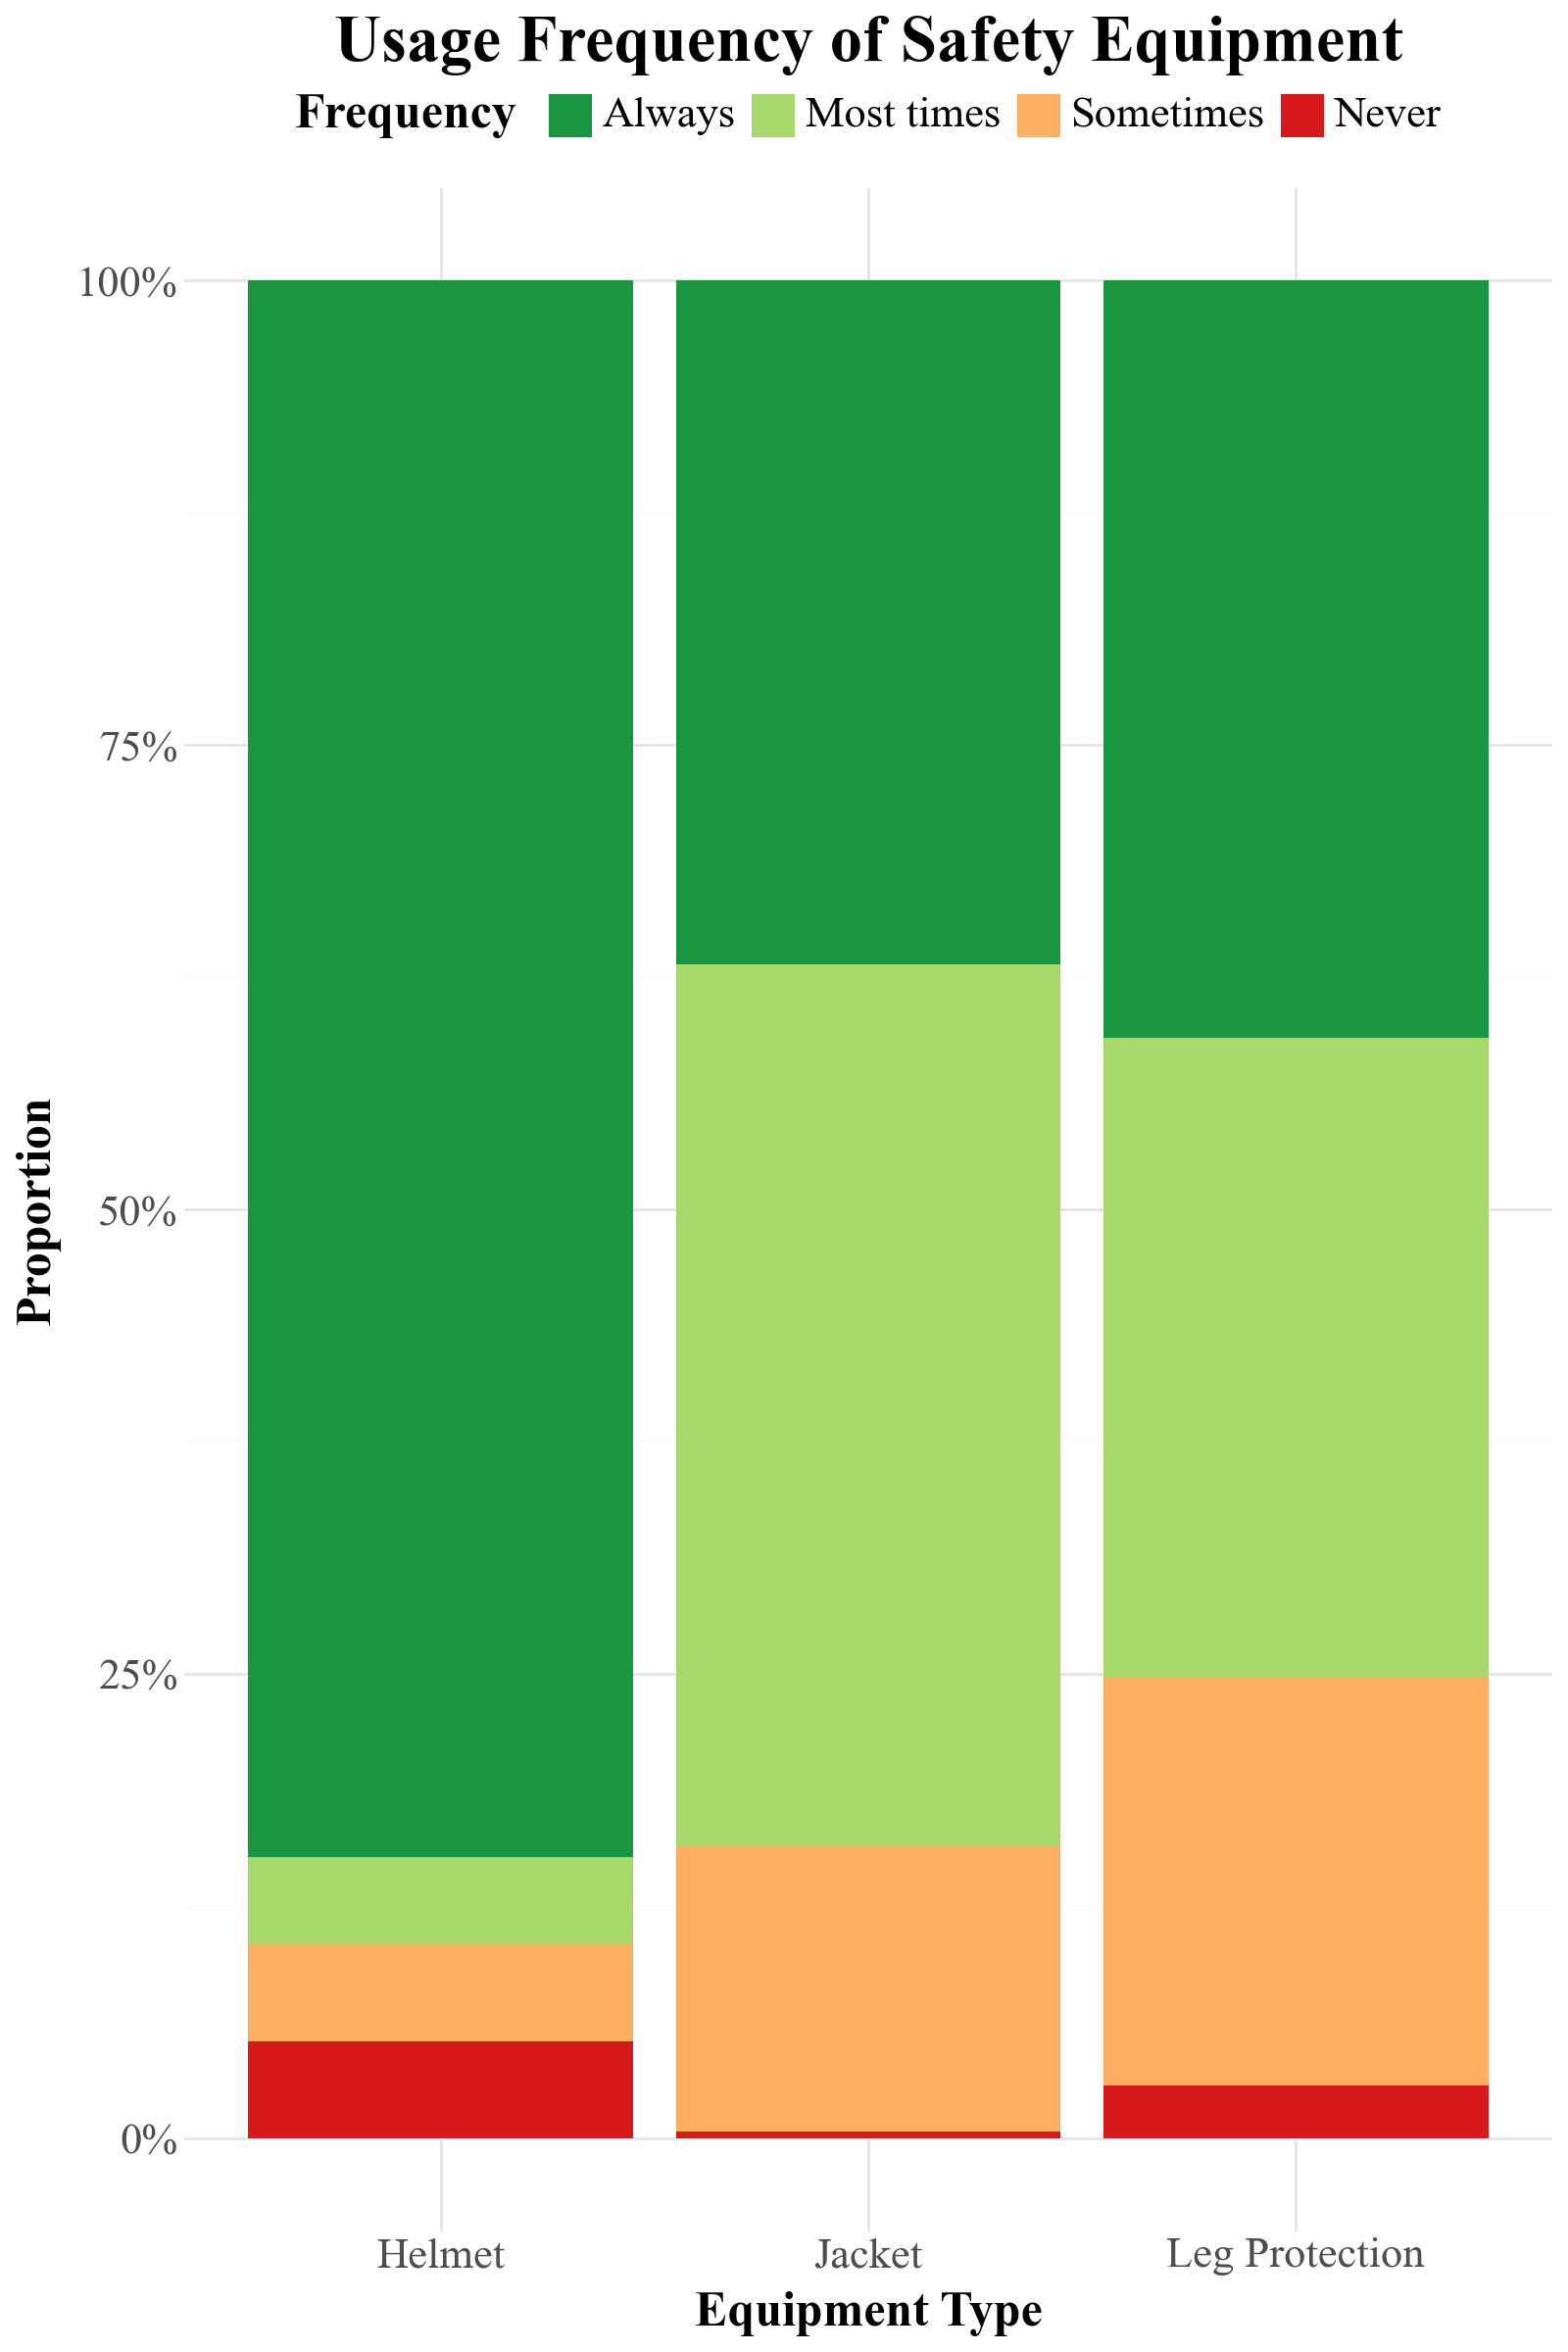

In [14]:
plot_global = (
    ggplot(ppe_df, aes(x='PPE_Type', fill='Usage'))
    + geom_bar(position="fill")
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment", x="Equipment Type", y="Proportion", fill="Frequency")
    + shared_theme
)
plot_global.save(FIGURES_DIR / "refined_ppe_usage.png", dpi=300)
plot_global

PPE_Type
Jacket            546
Leg Protection    314
Helmet              0
Name: count, dtype: int64


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage_x_city_no_helmet.png


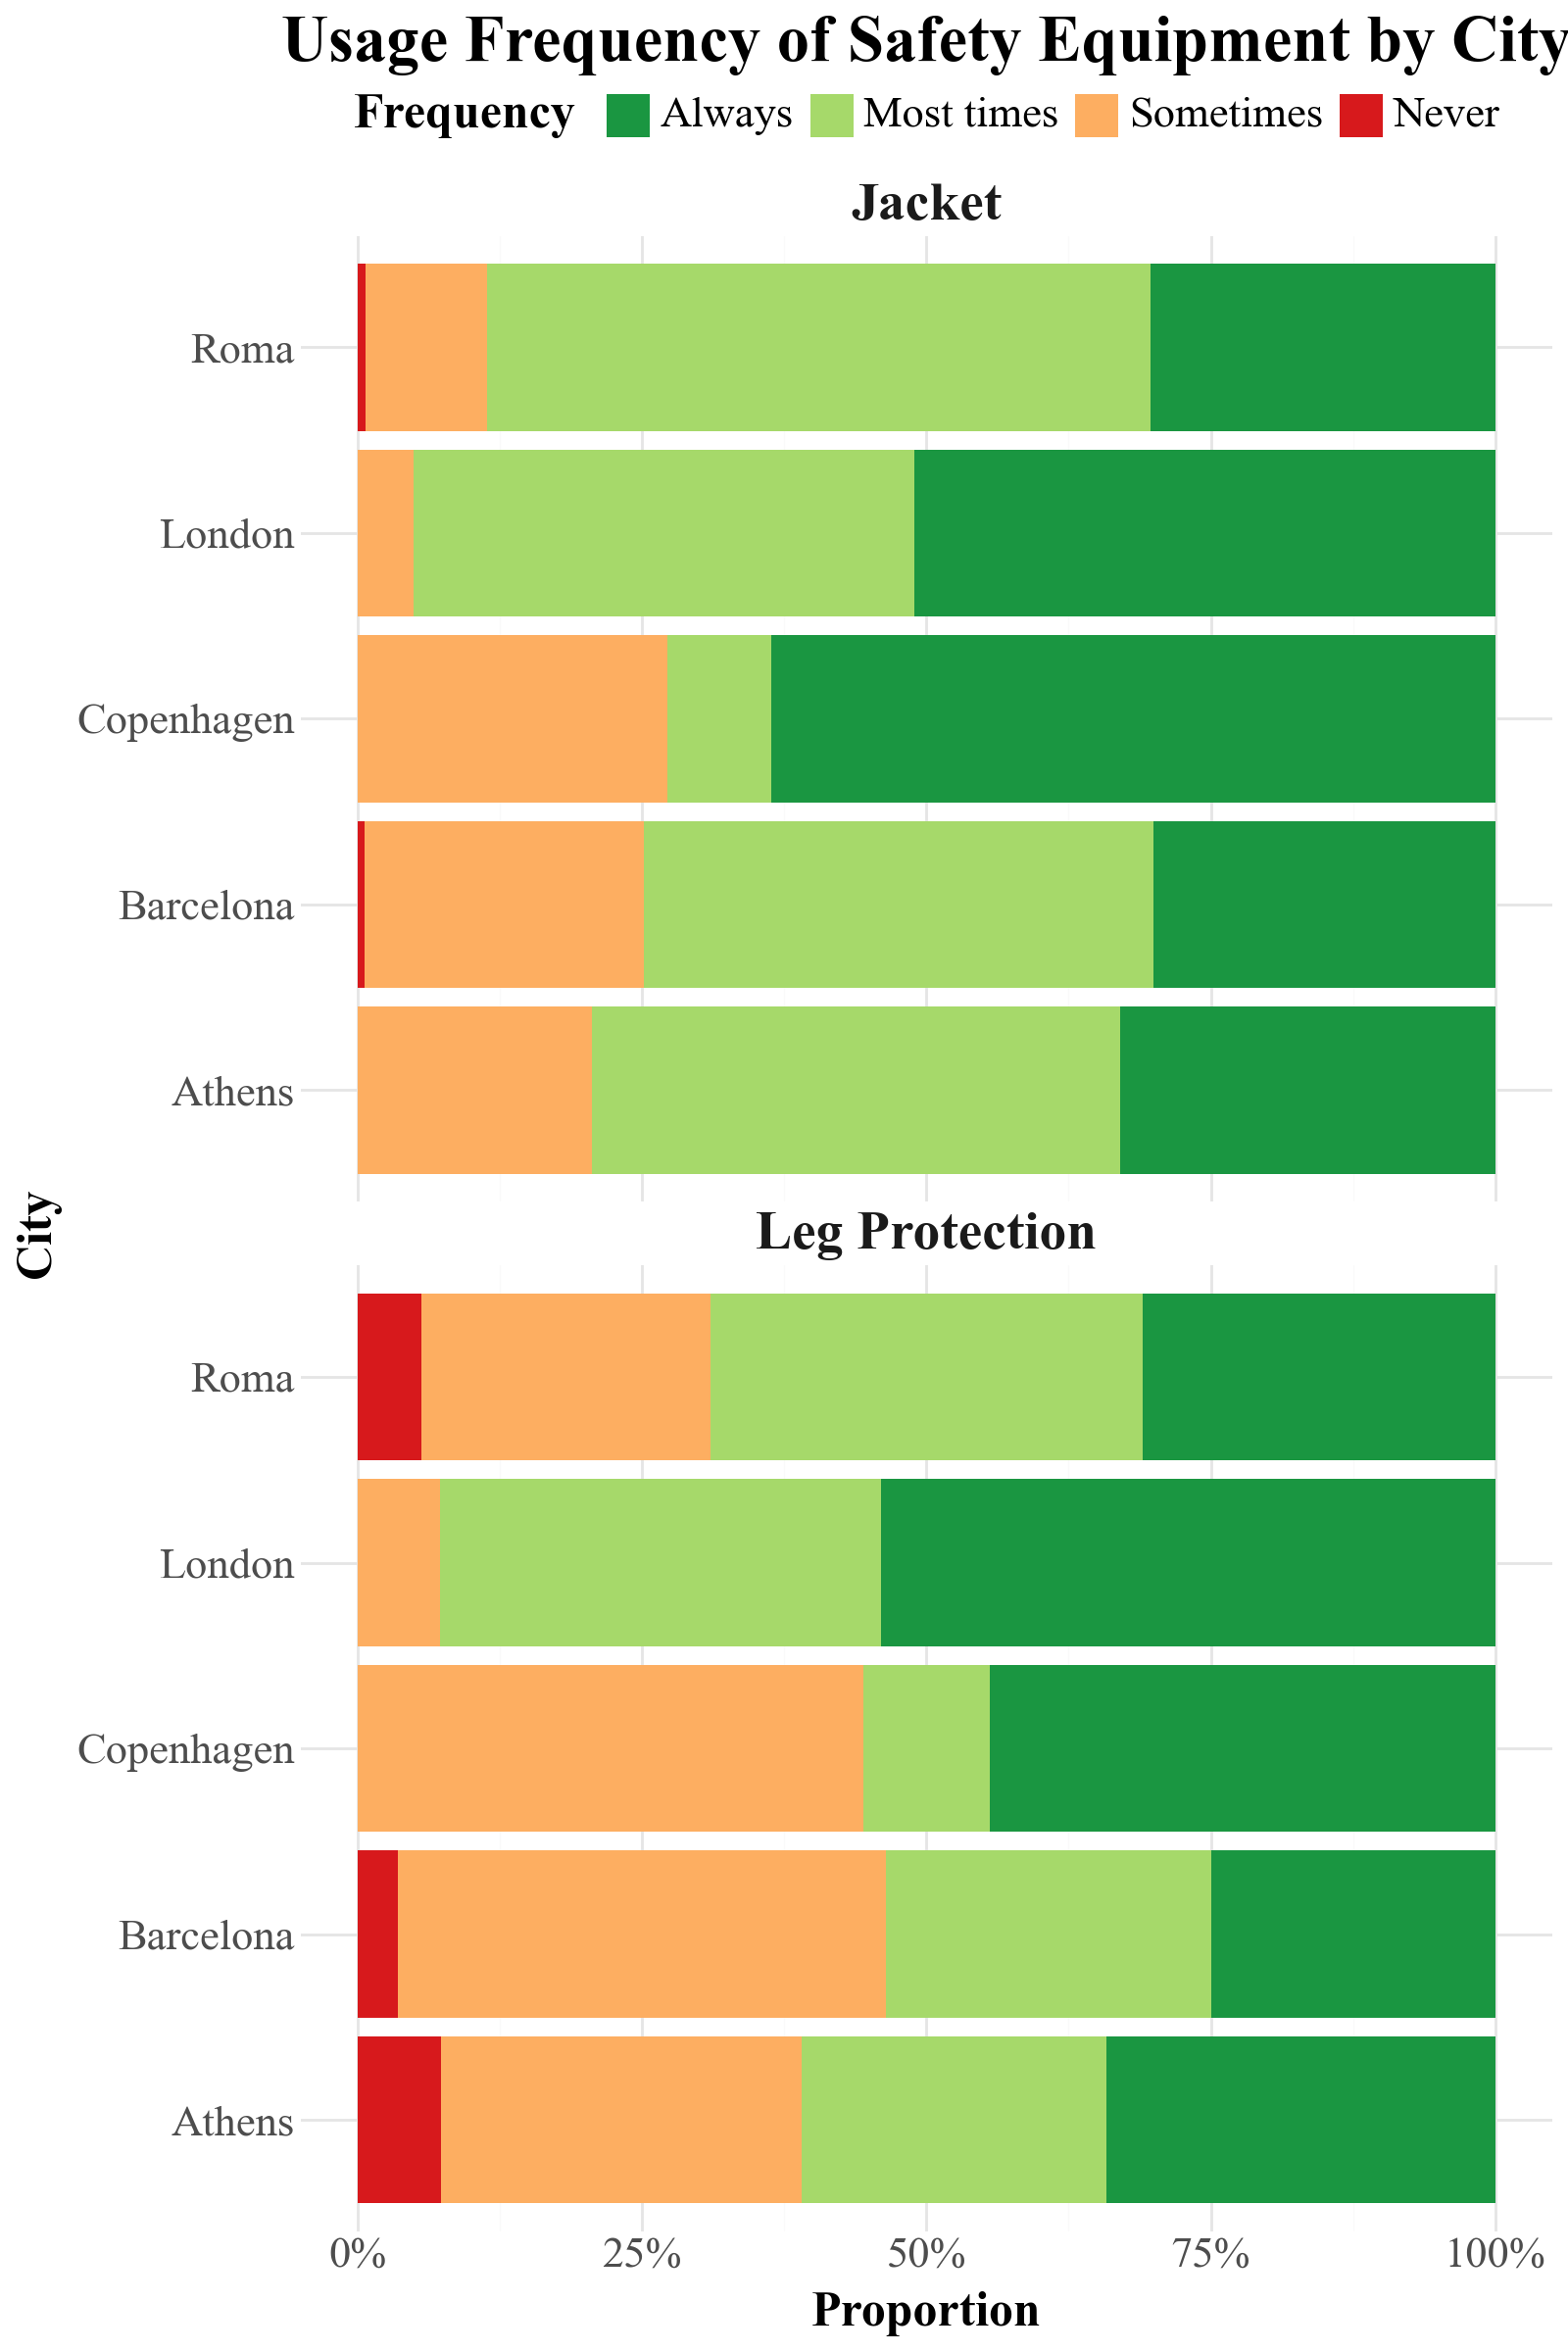

In [21]:
ppe_df_without_hermet = ppe_df[ppe_df["PPE_Type"]!="Helmet"]
print(ppe_df_without_hermet["PPE_Type"].value_counts())

plot_city = (
    ggplot(ppe_df_without_hermet, aes(x='City', fill='Usage'))
    + geom_bar(position="fill")
    + coord_flip() 
    + facet_wrap('~PPE_Type', ncol=1) 
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment by City", x=None, y="Proportion", fill="Frequency")
    + shared_theme
)
plot_city.save(FIGURES_DIR / "refined_ppe_usage_x_city_no_helmet.png", dpi=300)
plot_city

PPE_Type
Leg Protection    314
Helmet              0
Jacket              0
Name: count, dtype: int64


c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:623: PlotnineWarning: Saving 8 x 12 in image.
c:\Users\LucaLiebscht\Desktop\improva\.venv\Lib\site-packages\plotnine\ggplot.py:624: PlotnineWarning: Filename: C:\Users\LucaLiebscht\Desktop\improva\reports\figures\refined_ppe_usage_x_city_only_leg.png


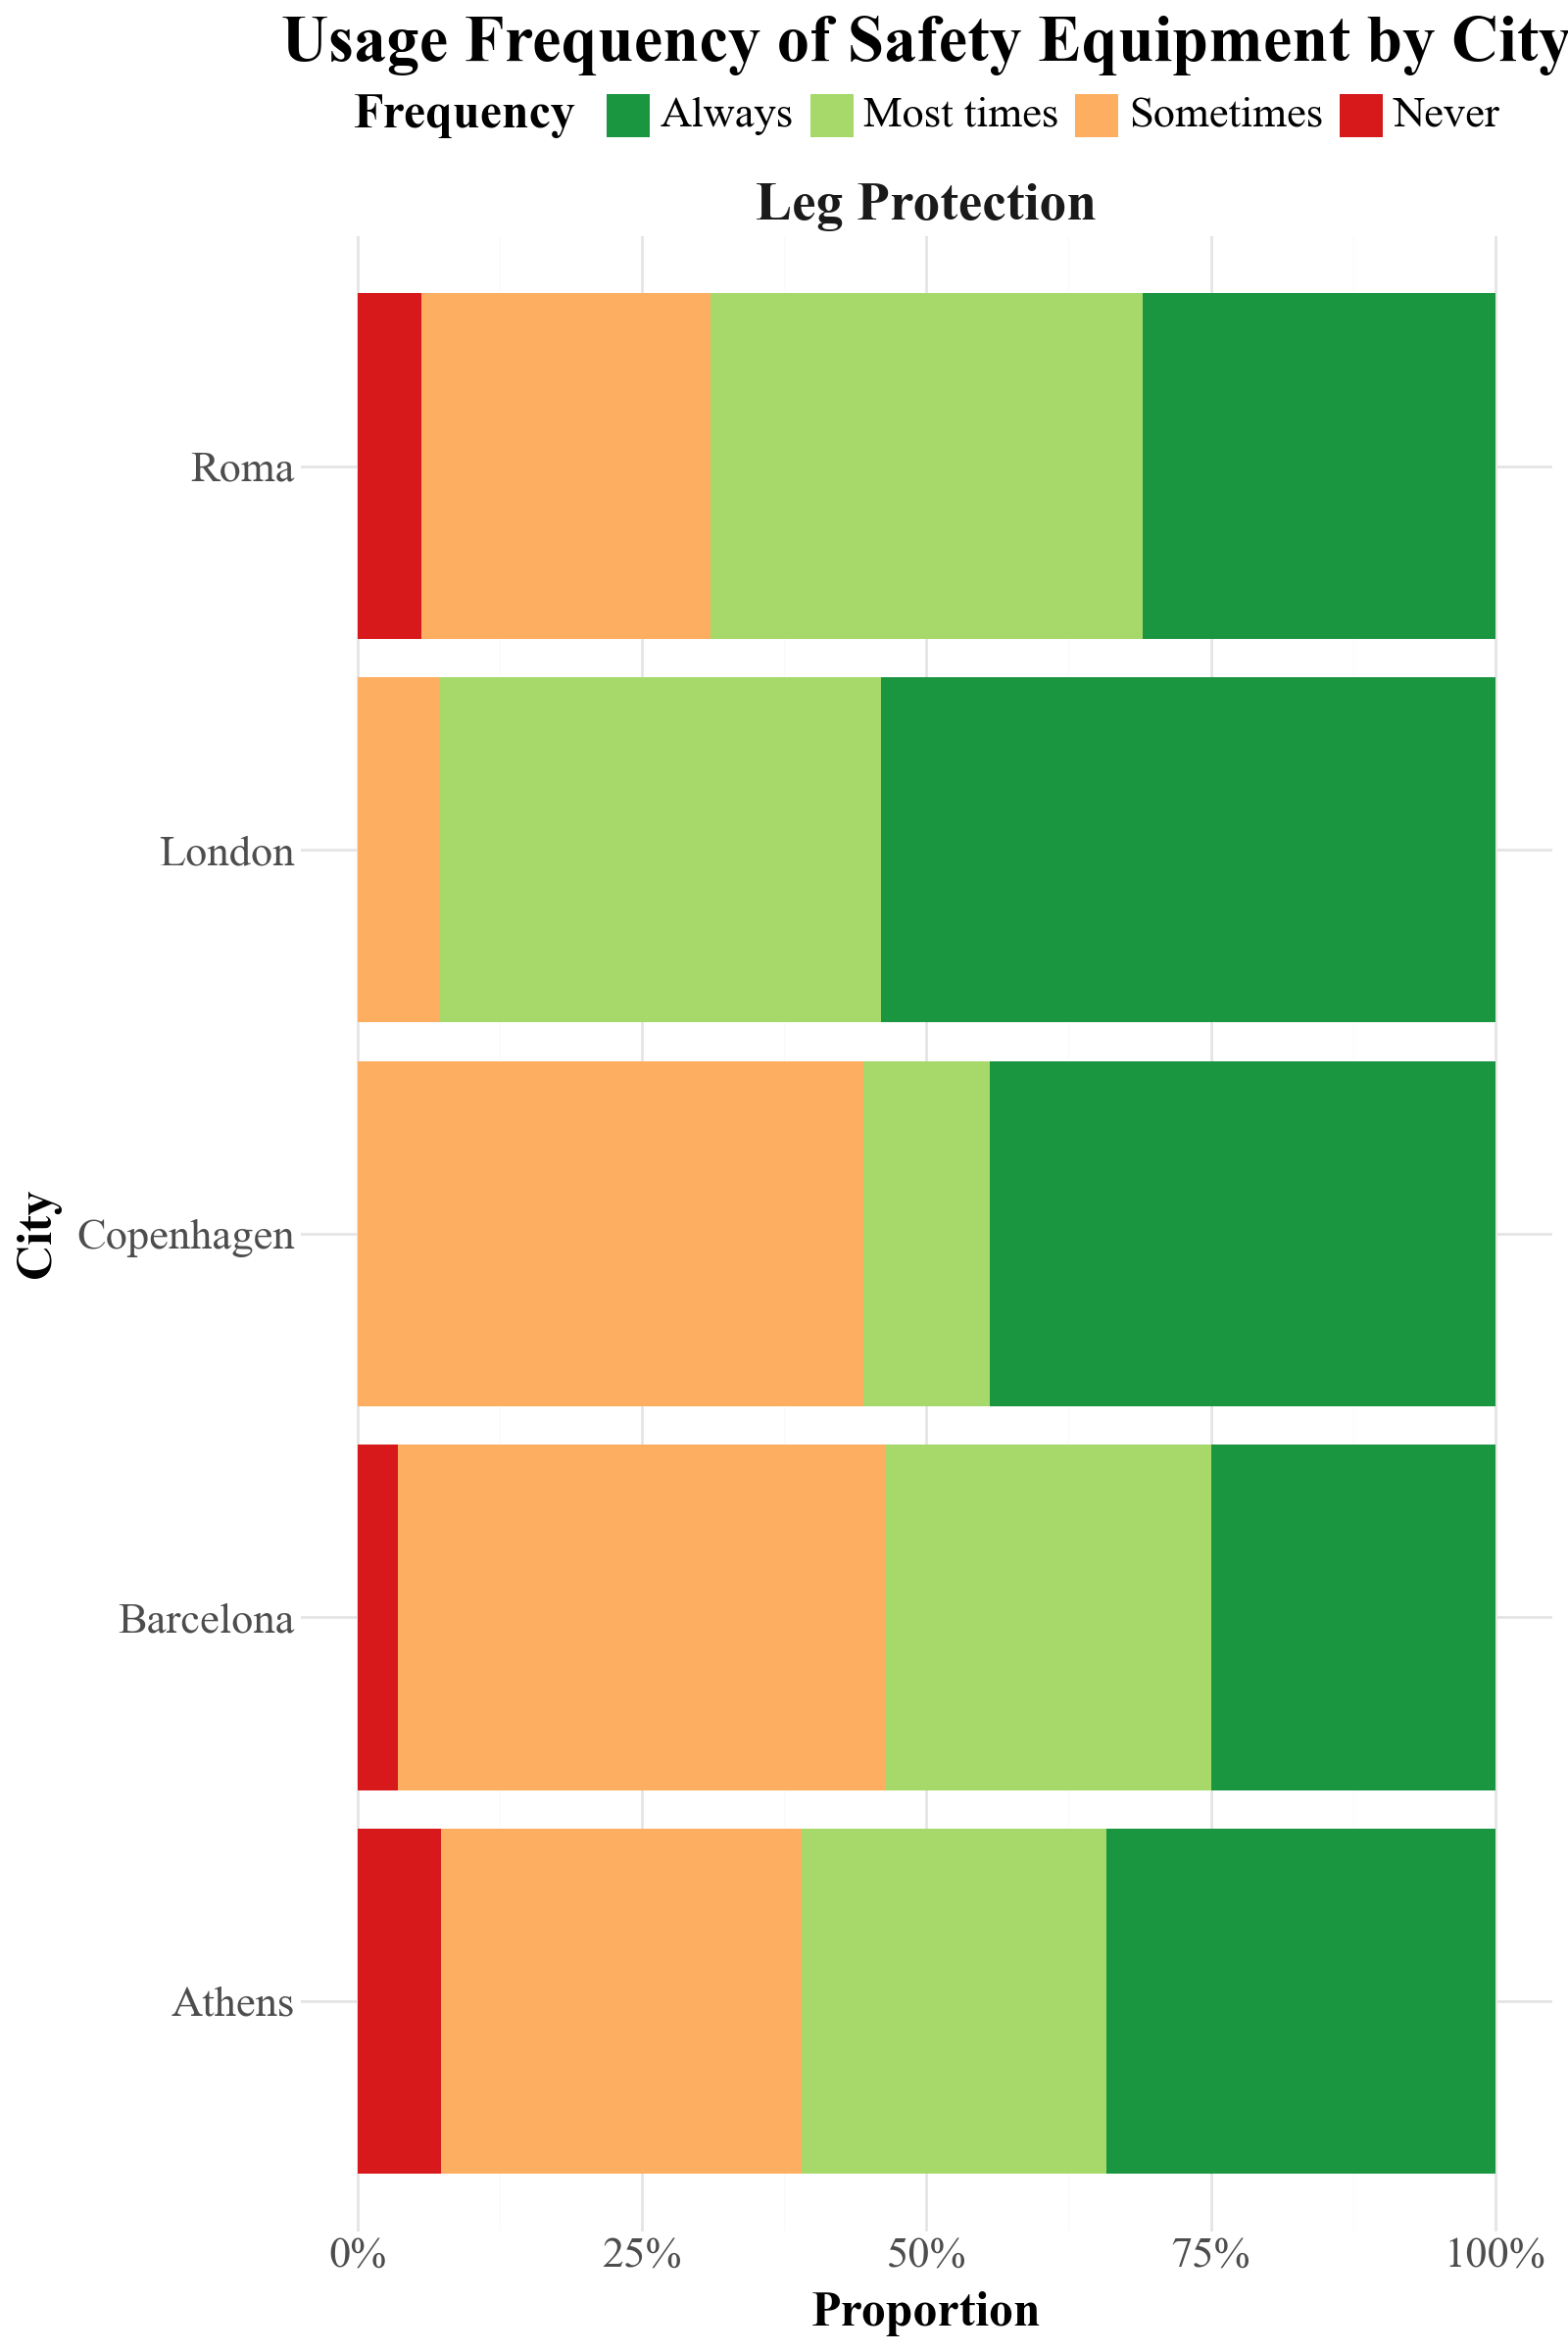

In [23]:

ppe_df_leg_only = ppe_df[ppe_df["PPE_Type"]=="Leg Protection"]
print(ppe_df_leg_only["PPE_Type"].value_counts()
)

plot_city = (
    ggplot(ppe_df_leg_only, aes(x='City', fill='Usage'))
    + geom_bar(position="fill")
    + coord_flip() 
    + facet_wrap('~PPE_Type', ncol=1) 
    + scale_y_continuous(labels=lambda l: [f"{int(x*100)}%" for x in l])
    + scale_fill_brewer(type="div", palette="RdYlGn", direction=-1)
    + labs(title="Usage Frequency of Safety Equipment by City", x=None, y="Proportion", fill="Frequency")
    + shared_theme
)
plot_city.save(FIGURES_DIR / "refined_ppe_usage_x_city_only_leg.png", dpi=300)
plot_city

# Save data